### Downscaling example: fluvial-pluvial compound flooding in Woodville, Texas

First, set up a Python environment to use as this notebook's kernel:
```bash
conda create -n dd-env python=3.12 --yes
conda activate dd-env
pip install git+https://github.com/passaH2O/depth-downscaler.git
pip install "depth-downscaler[examples]"
```

In [1]:
import contextily as cx
import geopandas as gpd
import depth_downscaler as dd
import matplotlib.pyplot as plt
import numpy as np
import rasterio as rio

from matplotlib.colors import ListedColormap, BoundaryNorm
from rasterio.plot import plotting_extent


This cell can be ignored; it defines some convenient plotting functions for this notebook.

In [2]:
# ---- plotting helpers ------------------------------------------------------
# These wrap the patterns reused across the plotting cells below: reading a
# raster, applying our standard UTM 15N axis labels, adding the Esri imagery
# basemap, plotting fluv+pluv raster pairs, and plotting a single raster with
# a basemap and zoom window.

# zoomed-in window in central Woodville, TX (UTM 15N: minx, maxx, miny, maxy)
ZOOM = (363265.1, 365193.0, 3404950.0, 3406464.8)


def read_band1(path):
    """Read band 1 of a raster; return (array, plotting_extent, crs)."""
    with rio.open(path) as ds:
        return ds.read(1), plotting_extent(ds), ds.crs


def style_utm_axes(ax, title, decimate_ticks=False):
    """Apply UTM 15N axis labels and title; optionally thin overlapping ticks."""
    ax.set(
        title=title,
        xlabel="UTM 15N Easting [m]",
        ylabel="UTM 15N Northing [m]",
    )
    if decimate_ticks:
        ax.set_xticks(ax.get_xticks()[::2])
        ax.set_yticks(ax.get_yticks()[::2])


def add_imagery_basemap(ax, crs, alpha=0.7, zorder=0, **kwargs):
    """Add Esri WorldImagery basemap with our standard styling."""
    cx.add_basemap(
        ax,
        crs=crs,
        alpha=alpha,
        source=cx.providers.Esri.WorldImagery,
        zorder=zorder,
        **kwargs,
    )


def plot_fluv_pluv_pair(
    pluv_path,
    fluv_path,
    title,
    fluv_label="Fluv inun [m]",
    pluv_label="Pluv inun [m]",
    zoom=ZOOM,
):
    """Plot fluvial (Reds) over pluvial (cividis) rasters with basemap and zoom."""
    fluv, extent, crs = read_band1(fluv_path)
    pluv, _, _ = read_band1(pluv_path)

    fig, ax = plt.subplots()
    imf = ax.imshow(
        fluv, extent=extent, cmap="Reds",
        interpolation="nearest", resample=False, zorder=1,
    )
    imp = ax.imshow(
        pluv, extent=extent, cmap="cividis",
        interpolation="nearest", resample=False, zorder=2,
    )
    add_imagery_basemap(
        ax, crs,
        attribution=False, interpolation="nearest", resample=False,
    )

    cbar_fluv = plt.colorbar(imf, ax=ax, fraction=0.046, pad=0.1)
    cbar_fluv.set_label(fluv_label)
    cbar_pluv = plt.colorbar(imp, ax=ax, fraction=0.046, pad=0.04)
    cbar_pluv.set_label(pluv_label)

    ax.set_xlim(zoom[0], zoom[1])
    ax.set_ylim(zoom[2], zoom[3])
    style_utm_axes(ax, title, decimate_ticks=True)
    return fig, ax


def plot_raster_with_basemap(
    path,
    title,
    zoom=ZOOM,
    basemap_alpha=0.7,
    mask_value=None,
    **imshow_kwargs,
):
    """Plot a single raster on Esri imagery, zoomed to `zoom`.

    Pass `mask_value` to make pixels with that value transparent.
    Returns (fig, ax, im) so the caller can build a custom colorbar.
    """
    arr, extent, crs = read_band1(path)
    if mask_value is not None:
        arr = np.ma.masked_equal(arr, mask_value)

    fig, ax = plt.subplots()
    im = ax.imshow(
        arr, extent=extent,
        interpolation="nearest", resample=False, zorder=2,
        **imshow_kwargs,
    )
    ax.set_xlim(zoom[0], zoom[1])
    ax.set_ylim(zoom[2], zoom[3])
    add_imagery_basemap(ax, crs, alpha=basemap_alpha, zorder=1, attribution_size=4)
    style_utm_axes(ax, title, decimate_ticks=True)
    return fig, ax, im


First we download the input data and derived datasets:
- Inputs
    - `woodville_mesh.gpkg`: ponded water mesh
    - `woodville_usgs1m.tif`: DEM*
    - `fl.gpkg`: river flowlines*
    - `catch.gpkg`: catchments*
- Derived inputs
    - `woodville_usgs1m_HAND_taudem.tif`: HAND raster
    - `woodville_detrended.tif`: per-mesh cell elevation detrended DEM
    - `woodville_detrended_cellids.tif`: raster mapping mesh cells to DEM pixels
    - `woodville_retraced_fl_segments.gpkg`: segmented river network
    - `woodville_segment_catchments.gpkg`: catchments for each river segment

See `00_woodville_data.ipynb` for how the derived inputs were prepared

*These files are only used to derive other inputs, and are not used in the downscaling workflow.

In [3]:
!curl https://utexas.box.com/shared/static/4839qusz2hhm8xhscr57kbyj470cuy1s.gpkg -Lso woodville_mesh.gpkg
# !curl https://utexas.box.com/shared/static/p0o0yfo1brzpoy8dqynl2dv2ht7s343b.tif  -Lso woodville_usgs1m.tif
# !curl https://utexas.box.com/shared/static/8xkxf3t0pc5xnrlb4auwkrltcktv07pc.gpkg -Lso fl.gpkg
# !curl https://utexas.box.com/shared/static/1k4dngc7vaucb4t2y2cpdoqur2nv5gjm.gpkg -Lso catch.gpkg

!curl https://utexas.box.com/shared/static/jr7k1ulckgrddb8szosk574ufjymtvnf.tif -Lso woodville_usgs1m_HAND_taudem.tif
!curl https://utexas.box.com/shared/static/qhjq5dbj6kkt8zn99xusgl8b5n0gz128.tif -Lso woodville_detrended.tif
!curl https://utexas.box.com/shared/static/6rctkwivt4s4sbrj5tnk6csucsbuhk3h.tif -Lso woodville_detrended_cellids.tif
!curl https://utexas.box.com/shared/static/ppinu9h926gfnkzzu0d2znbso70kj53b.gpkg -Lso woodville_retraced_fl_segments.gpkg
!curl https://utexas.box.com/shared/static/q2g0qvwd14mmca4ma5q96yq5jljl4a8k.gpkg -Lso woodville_segment_catchments.gpkg

We will refine the ponded water depths from the coarse mesh with the volume conservative downscaling method implemented in `depth-downscaler`. The mesh has three columns:
- `element_ID`: mesh cell index
- `r1_s500`: ponded water depth in meters at each cell
- `geometry`: mesh cell geometry

In [4]:
mesh_path = "woodville_mesh.gpkg"
mesh = gpd.read_file(mesh_path)
mesh.head()

,element_ID,r1_s500,geometry
0,52847,0.004610,"POLYGON Z ((362210.527 3405358.468 90.405, 362..."
1,52855,0.021014,"POLYGON Z ((362279.897 3405149.326 91.629, 362..."
2,52856,0.005869,"POLYGON Z ((361585.827 3405521.793 98.215, 361..."
3,52857,0.029092,"POLYGON Z ((362443.919 3405522.532 83.904, 362..."
4,52858,0.012755,"POLYGON Z ((362210.527 3405358.468 90.405, 362..."


Let's visualize the ponded water data that we will refine.

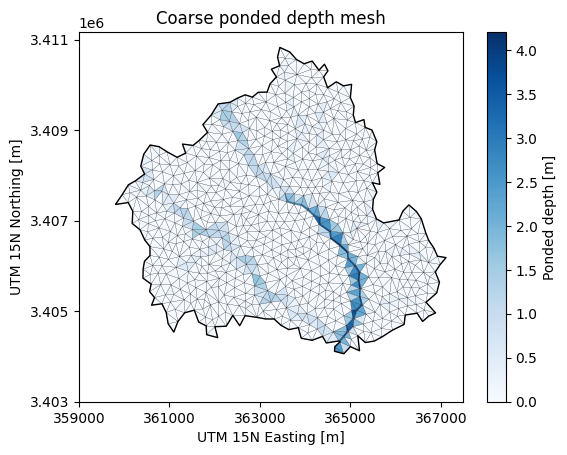

In [5]:
fig, ax = plt.subplots()
mesh.plot(
    ax=ax,
    column="r1_s500",
    cmap="Blues",
    legend=True,
    legend_kwds={"label": "Ponded depth [m]"},
)
mesh.boundary.plot(ax=ax, edgecolor="black", linewidth=0.1)
mesh.dissolve().boundary.plot(ax=ax, edgecolor="black", linewidth=1)
style_utm_axes(ax, "Coarse ponded depth mesh", decimate_ticks=True)
plt.show()


Now that our input data is prepared, we will run the downscaling method. First we set paths to input and output data.

In [6]:
# input paths
mesh_path = "woodville_mesh.gpkg"                       # ponded depth mesh to downscale (refine)
pw_field = "r1_s500"                                    # field in mesh with ponded depth in meters
detrended_dem_path = "woodville_detrended.tif"          # detrended 1m DEM
cell_ids_path = "woodville_detrended_cellids.tif"       # raster mapping DEM pixels to mesh cells
hand_path = "woodville_usgs1m_HAND_taudem.tif"          # Height Above Nearest Drainage (HAND) raster
segments_path = "woodville_retraced_fl_segments.gpkg"   # river channel network (retraced on 1m DEM)
segcatch_path = "woodville_segment_catchments.gpkg"     # catchments for 1 to 1.5 km segments of the retraced flowlines

# output paths
catch_ids_path = "woodville_catchids.tif"               # raster mapping DEM pixels to river segment catchments
inun_full_mesh_path = "woodville_inun_full_mesh.tif"    # intermediate raster used to identify fluvial mesh cells
inun_pluv_iter0_path = "woodville_inun_pluv_iter0.tif"  # intermediate raster with initial pluvial inundation estimate
inun_fluv_iter0_path = "woodville_inun_fluv_iter0.tif"  # intermediate raster with initial fluvial inundation estimate
out_inun_path = "woodville_inun_final.tif"              # final downscaled compound fluvial/pluvial inundation depth and extent
out_label_path = "woodville_inun_final_labels.tif"      # final inundation decomposed into fluvial and pluvial components

1. Downscale within full mesh for initial fluvial/pluvial classification

In [7]:
dd.downscale(
    elev_path=detrended_dem_path,
    downscaling_polygons_path=mesh_path,
    pw_mesh_path=mesh_path,
    out_inun_path=inun_full_mesh_path,
    pw_field=pw_field,
    polygon_ids_path=cell_ids_path,
)

calculating stage-volume table
stage-volume table saved to stage_vol_aece4bc6.pkl
inundation written to woodville_inun_full_mesh.tif


2. Initial classification of mesh cells as fluvial or pluvial

  163 cells directly touch streams
No distance limit, checking all mesh cells for inundation...
  259 cells with >= 33% inundated
  286 candidate fluvial cells (streams + inundated)
  252 contiguous fluvial cells


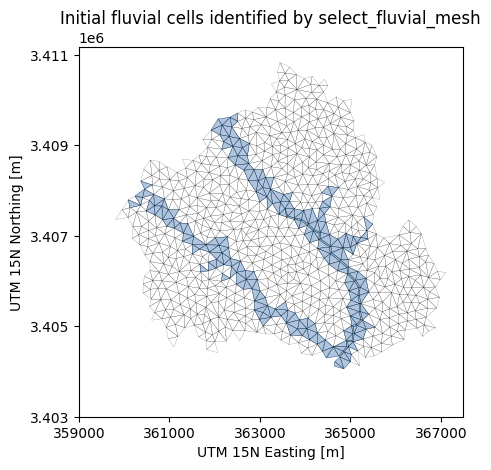

In [8]:
fluvial_ids_gdf = dd.select_fluvial_mesh(
    mesh=mesh,
    segments=segments_path,
    inundation_path=inun_full_mesh_path,
)

# plot the initial fluvial mesh cells
fig, ax = plt.subplots()
mesh.boundary.plot(ax=ax, edgecolor="black", linewidth=0.1)
fluvial_ids_gdf.plot(ax=ax, facecolor="lightsteelblue", edgecolor="steelblue", linewidth=0.3)
style_utm_axes(ax, "Initial fluvial cells identified by select_fluvial_mesh", decimate_ticks=True)
plt.show()


In [9]:
# allocate each cell's volume to initial fluvial and pluvial components

split_mesh = dd.split_fluvial_pluvial(
    fluvial_ids=fluvial_ids_gdf["element_ID"],
    mesh=mesh,
    pw_field=pw_field,
)

split_mesh.head()

Fluvial elements: 252
Pluvial elements: 1196
Total elements: 1448


,element_ID,r1_s500,geometry,r1_s500_fluv,r1_s500_pluv
0,52847,0.004610,"POLYGON Z ((362210.527 3405358.468 90.405, 362...",0.0,0.004610
1,52855,0.021014,"POLYGON Z ((362279.897 3405149.326 91.629, 362...",0.0,0.021014
2,52856,0.005869,"POLYGON Z ((361585.827 3405521.793 98.215, 361...",0.0,0.005869
3,52857,0.029092,"POLYGON Z ((362443.919 3405522.532 83.904, 362...",0.0,0.029092
4,52858,0.012755,"POLYGON Z ((362210.527 3405358.468 90.405, 362...",0.0,0.012755


3. Downscale an initial inundation map for the pluvial component of flooding

In [10]:
dd.downscale(
    elev_path=detrended_dem_path,
    downscaling_polygons_path=mesh_path,
    pw_mesh_path=split_mesh,
    out_inun_path=inun_pluv_iter0_path,
    pw_field=f"{pw_field}_pluv",
    polygon_ids_path=cell_ids_path,
)

loading stage-volume table from stage_vol_aece4bc6.pkl
inundation written to woodville_inun_pluv_iter0.tif


4. Downscale an initial inundation map for the fluvial component of flooding

In [11]:
# make raster mapping catchments to pixels for fluvial downscaling
catchments = dd.clean_segment_catchments(segcatch_path)
with rio.open(hand_path) as ds:
    hand_profile = ds.profile
catch_polygon_ids = dd.rasterize_polygon_ids(catchments, hand_profile)
dd.write_polygon_ids(catch_polygon_ids, hand_profile, catch_ids_path)

# initial fluvial downscale
dd.downscale(
    elev_path=hand_path,
    downscaling_polygons_path=segcatch_path,
    pw_mesh_path=split_mesh,
    out_inun_path=inun_fluv_iter0_path,
    pw_field=f"{pw_field}_fluv",
    polygon_ids_path=catch_ids_path,
)

polygon IDs written to woodville_catchids.tif
calculating stage-volume table
stage-volume table saved to stage_vol_bbd4380c.pkl
inundation written to woodville_inun_fluv_iter0.tif


Plotting the results on a zoomed in window in central Woodville, we can see that the initial downscaled fluvial and pluvial inundation maps overlap. The following cells resolve this overlap.

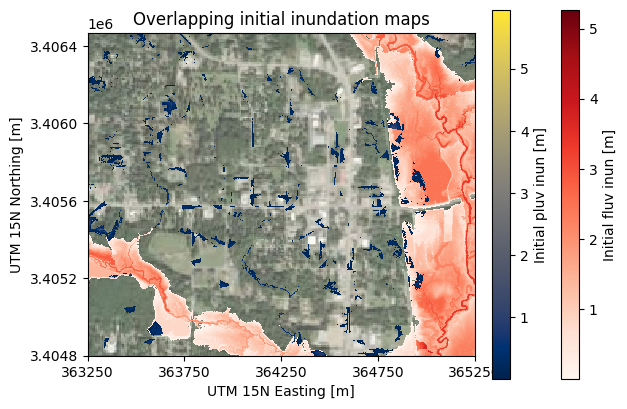

In [12]:
fig, ax = plot_fluv_pluv_pair(
    pluv_path=inun_pluv_iter0_path,
    fluv_path=inun_fluv_iter0_path,
    title="Overlapping initial inundation maps",
    fluv_label="Initial fluv inun [m]",
    pluv_label="Initial pluv inun [m]",
)
plt.show()


5. Iterative volume redistribution to resolve overlaps between initial pluvial and fluvial downscaling results

In [13]:
final_pluv_path, final_fluv_path, history, threshold_volume = dd.redistribute_volume(
    inun_pluv_path=inun_pluv_iter0_path,
    inun_fluv_path=inun_fluv_iter0_path,
    split_mesh=split_mesh,
    mesh_path=mesh_path,
    detrended_dem_path=detrended_dem_path,
    hand_path=hand_path,
    segcatch_path=segcatch_path,
    cell_ids_path=cell_ids_path,
    catch_ids_path=catch_ids_path,
    pw_field=pw_field,
)

------- Iteration 0 (initial state) -------
cells with overlapping inundation: 125
overlapping volume: 71714.4 m³ (1.29% of total)
convergence threshold: 7171.4 m³ (0.13% of total, 10% of initial overlap)

------- Iteration 1 -------
transferring overlap pluv -> fluv, downscaling again...
loading stage-volume table from stage_vol_aece4bc6.pkl
inundation written to /Users/markwang/repos/depth-downscaler/examples/woodville_inun_pluv_iter1.tif
loading stage-volume table from stage_vol_bbd4380c.pkl
inundation written to /Users/markwang/repos/depth-downscaler/examples/woodville_inun_fluv_iter1.tif
cells with overlapping inundation: 126
overlapping volume: 22146.7 m³ (0.40% of total)

------- Iteration 2 -------
transferring overlap pluv -> fluv, downscaling again...
loading stage-volume table from stage_vol_aece4bc6.pkl
inundation written to /Users/markwang/repos/depth-downscaler/examples/woodville_inun_pluv_iter2.tif
loading stage-volume table from stage_vol_bbd4380c.pkl
inundation written

Let's plot the results of the volume redistribution step to see how overlapping volume is reduced after each iteration

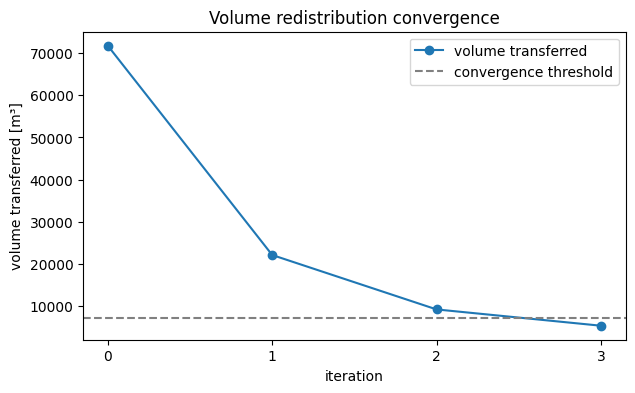

In [14]:
# plot convergence history
iters = [h["iter"] for h in history]
vols = [h["volume"] for h in history]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(iters, vols, "o-", label="volume transferred")
if threshold_volume:
    ax.axhline(threshold_volume, ls="--", color="gray", label=f"convergence threshold")
ax.set(
    xlabel="iteration",
    ylabel="volume transferred [m³]",
    title="Volume redistribution convergence",
    xticks=iters,
)
ax.legend()
plt.show()

Let's also visualize the final overlap that is within our 10% initial overlap tolerance

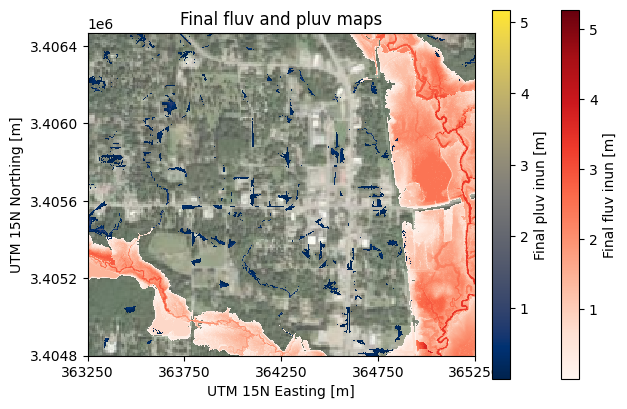

In [15]:
fig, ax = plot_fluv_pluv_pair(
    pluv_path=final_pluv_path,
    fluv_path=final_fluv_path,
    title="Final fluv and pluv maps",
    fluv_label="Final fluv inun [m]",
    pluv_label="Final pluv inun [m]",
)
plt.show()


6. Finally, let's combine the final pluvial and fluvial downscaling results to obtain:
- final inundation depth
- fluvial/pluvial classification labels

Note: we take the fluvial inundation depth at fluv/pluv overlaps. This introduces a volume error of about 0.1%, which is within the uncertainty of the input data.

In [16]:
dd.stack_inun(
    inun_pluv_path=final_pluv_path,
    inun_fluv_path=final_fluv_path,
    out_path=out_inun_path,
)
dd.label_inundation(
    inun_pluv_path=final_pluv_path,
    inun_fluv_path=final_fluv_path,
    out_path=out_label_path,
)

Compound inundation raster written to woodville_inun_final.tif
Labeled inundation written to woodville_inun_final_labels.tif


Now we can view the final compound inundation map, as well as the fluvial/pluvial classification labels

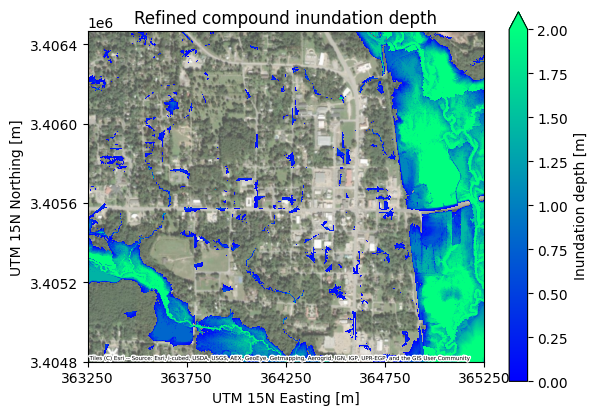

In [17]:
fig, ax, im = plot_raster_with_basemap(
    out_inun_path,
    title="Refined compound inundation depth",
    cmap="winter",
    vmin=0,
    vmax=2,
)
plt.colorbar(im, ax=ax, label="Inundation depth [m]", extend="max")
plt.show()


We plot the original coarse ponded water mesh for comparison

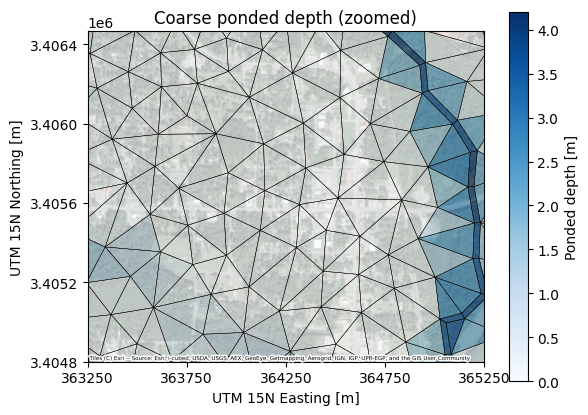

In [18]:
# coarse mesh on the same basemap + zoom window as the downscaled plots,
# for side-by-side visualization of the resolution improvement
fig, ax = plt.subplots()
mesh.plot(
    ax=ax,
    column="r1_s500",
    cmap="Blues",
    legend=True,
    legend_kwds={"label": "Ponded depth [m]"},
    alpha=0.6,
    zorder=2,
)
mesh.boundary.plot(ax=ax, edgecolor="black", linewidth=0.3, zorder=3)
ax.set_xlim(ZOOM[0], ZOOM[1])
ax.set_ylim(ZOOM[2], ZOOM[3])
add_imagery_basemap(ax, mesh.crs, alpha=0.7, zorder=1, attribution_size=4)
style_utm_axes(ax, "Coarse ponded depth (zoomed)", decimate_ticks=True)
plt.show()

We can also decompose the inundation extents into fluvial and pluvial components

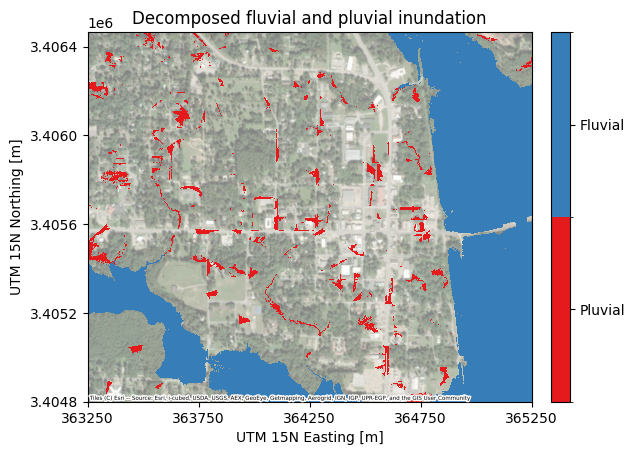

In [19]:
# discrete 2-color cmap: 1 -> pluvial, 2 -> fluvial
cmap = ListedColormap(plt.get_cmap("Set1").colors[:2])
norm = BoundaryNorm([0.5, 1.5, 2.5], cmap.N)

fig, ax, im = plot_raster_with_basemap(
    out_label_path,
    title="Decomposed fluvial and pluvial inundation",
    basemap_alpha=0.5,
    mask_value=0,  # mask "no inundation" so basemap shows through
    cmap=cmap,
    norm=norm,
)

cbar = plt.colorbar(im, ax=ax, ticks=[1, 2], fraction=0.046, pad=0.04)
cbar.set_ticklabels(["Pluvial", "Fluvial"])
plt.show()
